In [55]:
import numpy as np
import matplotlib.pyplot as pl
from scipy.interpolate import CubicSpline
import scipy as sp
from scipy import integrate

c = 3e8
G = 6.67e-11
pi = np.pi
const = 96/5*pi**(8/3)*(G/c**3)**(5/3)
day = 86400

## Interpolating ephemeris

In [56]:
ephemeris = np.loadtxt("earth00-40-DE440.dat", delimiter = '\t', skiprows=18)
[t_eph, pos_x, pos_y, pos_z, vel_x, vel_y, vel_z, acc_x, acc_y, acc_z] = ephemeris.T

pos_arr = np.array([pos_x, pos_y, pos_z])
interp_pos = CubicSpline(t_eph, pos_arr.T)
v_arr = np.array([vel_x, vel_y, vel_z])
interp_v = CubicSpline(t_eph, v_arr.T)
acc_arr = np.array([acc_x, acc_y, acc_z])
interp_acc = CubicSpline(t_eph, acc_arr.T)

## Injecting

In [233]:
def f_calc(f0, Mc, t):
    M = Mc*2e30
    beta = const*f0**(8/3)*M**(5/3)
    return f0*(1-8/3*beta*t)**(-3/8)

def df_calc(f0, Mc, t):
    M = Mc*2e30
    beta = const*f0**(8/3)*M**(5/3)
    return f0*beta*(1-8/3*beta*t)**(-11/8)

def phi_calc(f0, Mc, t):
    M = Mc*2e30
    beta = const*f0**(8/3)*M**(5/3)
    return -6*pi/5*f0*(1-8./3.*beta*t)**(5/8)/beta

def tMax_calc(f0, Mc, f_max):
    M = Mc*2e30
    beta = const*f0**(8/3)*M**(5/3)
    temp0 = 0.375/beta
    temp1 = 1-(f0/f_max)**(8/3)
    return temp0*temp1

In [76]:
H_lat = 119.41 * np.pi/180 # rad
H_lng = 46.45 * np.pi/180 # rad

params = dict(ra = 0.5, dec = 0.5, eta = 0.5, psi = 0.5, lat = H_lat, 
              lng = H_lng, az = 0.5)

n_hat = (np.cos(params['ra'])*np.cos(params['dec']),
        np.sin(params['ra'])*np.cos(params['dec']),
        np.sin(params['dec']))

f0 = 20
Mc = 1e-4* 2e30
beta = const*f0**(8/3)*Mc**(5/3)
fmax = 256
start_time = t_eph[abs(t_eph-(t_eph[0]+24*365*day)).argmin()] # very approximately 1st Jan 2024

## When we are using 10 day chunks for semicoherent search

In [144]:
def exact_calc(f0, Mc, semicoherent_length=10):
    duration = min(semicoherent_length*day, tMax_calc(f0, Mc, fmax))
    t_offset = np.linspace(0, duration, int(1e5))
    t_doppler = start_time + t_offset
    
    temp = f_calc(f0, Mc, t_offset)*(1+np.dot(interp_v(t_doppler), n_hat))
    return 2*np.pi*integrate.cumulative_trapezoid(temp, x=t_offset, initial=0)

def freqApprox_calc(f0, Mc, semicoherent_length=10):
    duration = min(semicoherent_length*day, tMax_calc(f0, Mc, fmax))
    t_offset = np.linspace(0, duration, int(1e5))
    t_doppler = start_time + t_offset
    
    beta = const*f0**(8/3)*Mc**(5/3)
    temp0 = f_calc(f0, Mc, t_offset)*(t_offset+np.dot(interp_pos(t_doppler), n_hat))
    temp1 =  -3/5*f0/beta*(-1+beta*t_offset)/(1-8/3*beta*t_offset)**(3/8)
    temp2 = 2*np.pi*(temp0 + temp1)
    return temp2 - temp2[0]

def phaseApprox_calc(f0, Mc, semicoherent_length=10):
    duration = min(semicoherent_length*day, tMax_calc(f0, Mc, fmax))
    t_offset = np.linspace(0, duration, int(1e5))
    t_doppler = start_time + t_offset
    
    beta = const*f0**(8/3)*Mc**(5/3)
    temp0 = phi_calc(f0, Mc, t_offset)*(1+np.dot(interp_v(t_doppler), n_hat))
    return temp0 - temp0[0]

In [142]:
def freqFinal_err(f0, Mc, semicoherent_length=10):
    exact_phase = exact_calc(f0, Mc, semicoherent_length)
    approx_phase = freqApprox_calc(f0, Mc, semicoherent_length)
    return abs(exact_phase[-1] - approx_phase[-1])

def freqRelative_err(f0, Mc, semicoherent_length=10):
    exact_phase = exact_calc(f0, Mc, semicoherent_length)
    approx_phase = freqApprox_calc(f0, Mc, semicoherent_length)
    return abs(exact_phase[-1] - approx_phase[-1])/exact_phase[-1]

def phaseFinal_err(f0, Mc, semicoherent_length=10):
    exact_phase = exact_calc(f0, Mc, semicoherent_length)
    approx_phase = phaseApprox_calc(f0, Mc, semicoherent_length)
    return abs(exact_phase[-1] - approx_phase[-1])

def phaseRelative_err(f0, Mc, semicoherent_length=10):
    exact_phase = exact_calc(f0, Mc, semicoherent_length)
    approx_phase = phaseApprox_calc(f0, Mc, semicoherent_length)
    return abs(exact_phase[-1] - approx_phase[-1])/exact_phase[-1]

## Verifying approximations work

### Frequency approx

$$\phi^{doppler}(t) = 2\pi f_s(t)\left[t+\frac{\vec{r} \cdot \hat{n}}{c}\right] - 2\pi \int f_s'(t)\left[t+\frac{\vec{r} \cdot \hat{n}}{c}\right] dt$$
Why is this not really similar to $\phi_s(t)$?

In [301]:
def integrated_fprimet(f0, Mc, t):
    M = Mc*2e30
    beta = const*f0**(8/3)*M**(5/3)
    return -3/5*f0/beta*(-1+beta*t)/(1-8/3*beta*t)**(3/8)

In [302]:
f0 = 20
Mc = 1e-4
duration = min(10*day, tMax_calc(f0, Mc, fmax))
t_offset = np.linspace(0, duration, int(1e5))
t_doppler = start_time + t_offset

In [303]:
exact = exact_calc(f0, Mc)
order1 = 2*np.pi*f_calc(f0, Mc, t_offset)*(t_offset+np.dot(interp_pos(t_doppler), n_hat))
order2 = 2*np.pi*integrated_fprimet(f0, Mc, t_offset)
test = df_calc(f0, Mc, t_offset)*(t_offset)
integrated_test = integrate.cumulative_trapezoid(test, x=t_offset, initial=0)

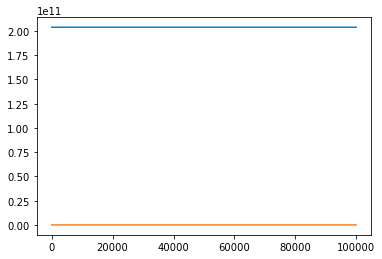

In [304]:
pl.plot(order2)
pl.plot(2*np.pi*integrated_test)

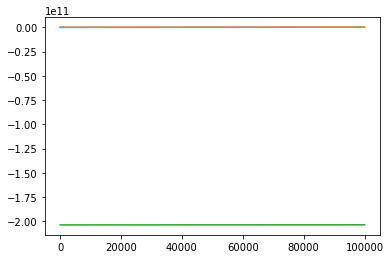

In [297]:
pl.plot(exact)
pl.plot(order1)
pl.plot(order1 - order2 - 2*np.pi*integrated_test)

### Phase approx

$$\phi^{doppler}(t) = \phi^0(t) (1+\frac{\vec{v} \cdot \hat{n}}{c})-\frac{\vec{a} \cdot \hat{n}}{c}\int\phi^0(t)dt$$

In [258]:
def phi_integrated(f0, Mc, t):
    M = Mc*2e30
    beta = const*f0**(8/3)*M**(5/3)
    temp = 18*np.pi*f0/(65*beta**2)*(1-8/3*beta*t)**(13/8)
#     temp = 6*np.pi*f0*t/(5*beta) * (1-8/3*beta*t)**(5/8)
    return temp - temp[0]

In [259]:
f0 = 20
Mc = 1e-2
duration = min(10*day, tMax_calc(f0, Mc, fmax))
t_offset = np.linspace(0, duration, int(1e5))
t_doppler = start_time + t_offset

In [267]:
phi = phi_calc(f0, Mc, t_offset)
numerical_integration = integrate.cumulative_trapezoid(phi, x=t_offset, initial=0)
analytical_integration = phi_integrated(f0, Mc, t_offset)

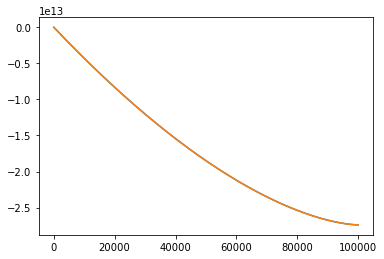

In [268]:
pl.plot(numerical_integration)
pl.plot(analytical_integration)

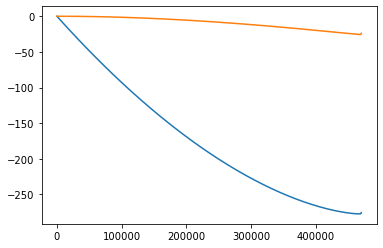

In [274]:
exact = exact_calc(f0, Mc)
test0 = phi_calc(f0, Mc, t_offset)*(1+np.dot(interp_v(t_doppler), n_hat))
test1 = test0 - np.dot(interp_acc(t_doppler), n_hat)*phi_integrated(f0, Mc, t_offset)

pl.plot(t_offset, exact-(test0-test0[0]))
pl.plot(t_offset, exact-(test1-test1[0]))
# pl.plot(t_offset, test - exact_calc(f0, Mc))

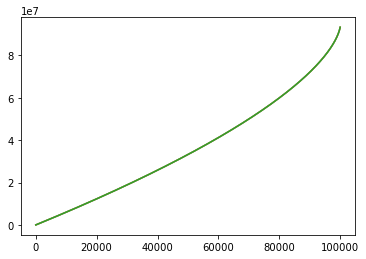

In [276]:
pl.plot(exact)
pl.plot(test0 - test0[0])
pl.plot(test1 - test1[0])

## Checking the error

In [172]:
semicoherent_length = 10
Mc_space = np.logspace(-7, 0, 50)
duration_arr = np.array([min(semicoherent_length*day, tMax_calc(f0, i, fmax)) for i in Mc_space])
phase_thresh = 1/duration_arr

freqFinal_err_arr = np.array([freqFinal_err(20, i, semicoherent_length) for i in Mc_space])
freqRelative_err_arr = np.array([freqRelative_err(20, i, semicoherent_length) for i in Mc_space])
phaseFinal_err_arr = np.array([phaseFinal_err(20, i, semicoherent_length) for i in Mc_space])
phaseRelative_err_arr = np.array([phaseRelative_err(20, i, semicoherent_length) for i in Mc_space])

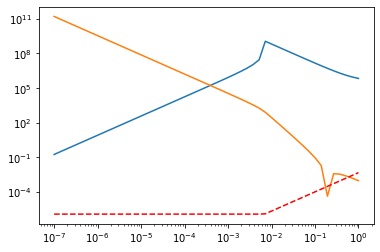

In [173]:
pl.loglog(Mc_space, freqFinal_err_arr)
pl.loglog(Mc_space, phaseFinal_err_arr)
pl.loglog(Mc_space, phase_thresh, c='r', ls='--')

## Testing integration by parts the other way

In [11]:
def df_calc(f0, beta, t):
    return f0*beta*(1-8/3*beta*t)**(-11/8)

def d2f_calc(f0, beta, t):
    return 11/3*f0*beta**2*(1-8/3*beta*t)**(-19/8)

In [12]:
# pl.plot(t_offset, [df_calc(f0, beta, i) for i in t_offset]) #O(1e-9) but doesn't start at 0
# pl.plot(t_offset, [d2f_calc(f0, beta, i) for i in t_offset]) #O(1e-17) but doesn't start at 0

$$\phi^{doppler}(t) = \int_0^t f_s(t)\left[1+\frac{\vec{v} \cdot \hat{n}}{c}\right]dt$$

$$\phi^{doppler}(t) = f_s(t)\left[t+\frac{\vec{r} \cdot \hat{n}}{c}\right] - \int f_s'(t)\left[t+\frac{\vec{r} \cdot \hat{n}}{c}\right] dt$$
Why is this not really similar to $\phi_s(t)$?

In [13]:
phi_source = phi_calc(f0, beta, t_offset)
phi_source -= phi_source[0] #be careful with this
f_source = f_calc(f0, beta, t_offset)
f_doppler = f_source*(1+np.dot(interp_v(t_doppler), n_hat))

# integrated_phi = integrate.cumulative_trapezoid(phi_source, x=t_space, initial=0)
# numerical_f = 1/(2*pi)*np.gradient(numerical_phi, np.diff(t_space)[0])

In [14]:
# # With the numerical integration
# phi_hypoth = f_source*(t_offset+np.dot(interp_pos(t_doppler), n_hat)) - integrated_temp
# f_hypoth = np.gradient(phi_hypoth, np.diff(t_offset)[0])
# pl.plot(t_offset/day, (f_hypoth - f_doppler)/f_doppler)
# pl.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


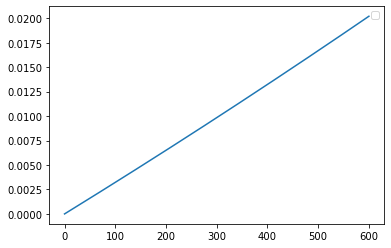

In [15]:
phi_hypoth = f_source*(t_offset+np.dot(interp_pos(t_doppler), n_hat))
f_hypoth = np.gradient(phi_hypoth, np.diff(t_offset)[0])
pl.plot(t_offset/day, (f_hypoth - f_doppler)/f_doppler)
pl.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


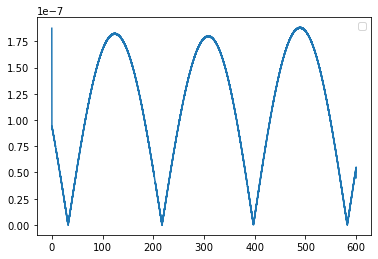

In [16]:
phi_hypoth = f_source*(t_offset+np.dot(interp_pos(t_doppler), n_hat)) - 3/5*f0/beta*(-1+(1-beta*t_offset)/(1-8/3*beta*t_offset)**(3/8))
f_hypoth = np.gradient(phi_hypoth, np.diff(t_offset)[0])
pl.plot(t_offset/day, abs((f_hypoth - f_doppler)/f_doppler))
pl.legend()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


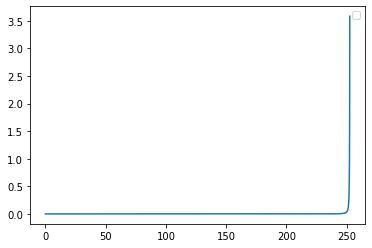

In [87]:
order0 = f_source*(t_offset+np.dot(interp_pos(t_doppler), n_hat))
order1 = 3/5*f0/beta*(-1+(1-beta*t_offset)/(1-8/3*beta*t_offset)**(3/8)) #analytic integral of df*t

temp = np.dot(interp_pos(t_doppler), n_hat)
secondOrder_integrated = integrate.cumulative_trapezoid(temp, x=t_offset, initial=0)
order2 = df_calc(f0, beta, t_offset)*secondOrder_integrated

phi_hypoth = order0 - order1 + order2
f_hypoth = np.gradient(phi_hypoth, np.diff(t_offset)[0])
pl.plot(t_offset/day, abs((f_hypoth - f_doppler)/f_doppler))
pl.legend()

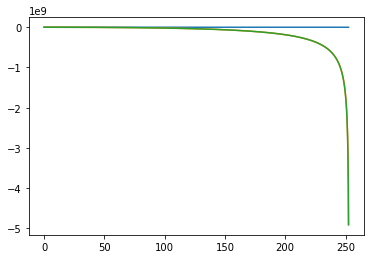

In [90]:
pl.figure(0)
temp = df_calc(f0, beta, t_offset)*np.dot(interp_pos(t_doppler), n_hat)
integrated_temp = integrate.cumulative_trapezoid(temp, x=t_offset, initial=0)
pl.plot(t_offset/day, integrated_temp)
pl.plot(t_offset/day, -order1)
pl.plot(t_offset/day, -order1+order2)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


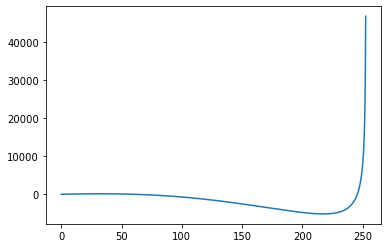

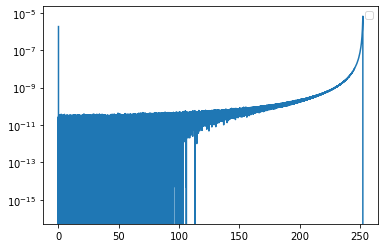

In [80]:
# With the quadratic numerical integration
pl.figure(1)
phi_hypoth = f_source*(t_offset+np.dot(interp_pos(t_doppler), n_hat)) - 3/5*f0/beta*(-1+(1-beta*t_offset)/(1-8/3*beta*t_offset)**(3/8)) - integrated_temp
f_hypoth = np.gradient(phi_hypoth, np.diff(t_offset)[0])
pl.semilogy(t_offset/day, ((f_hypoth - f_doppler)/f_doppler))
pl.legend()


## 1st order solution 

$$\phi^{doppler}(t) = \phi^0(t) (1+\frac{\vec{v} \cdot \hat{n}}{c})$$

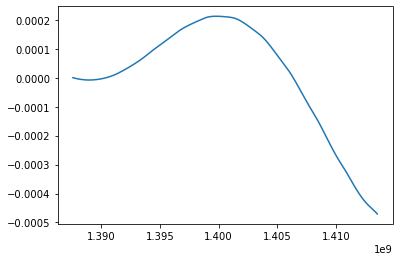

In [233]:
phi_source = phi_calc(f0, beta, t_space - t_space[0])
phi_source -= phi_source[0] #be careful with this
order1 = phi_source * (1+np.dot(interp_v(t_space), n_hat))

f_order1 = 1/(2*pi)*np.gradient(order1, np.diff(t_space)[0])
pl.plot(t_space, (f_order1 - f_doppler)/f_doppler)

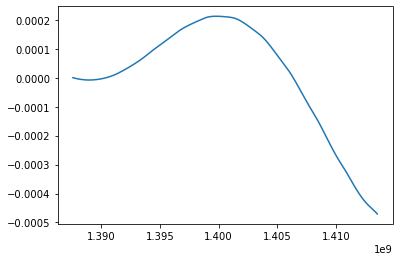

In [234]:
# pl.plot(t_space, f_doppler)
# pl.plot(t_space, f_approx)
pl.plot(t_space, (f_order1 - f_doppler)/f_doppler)

In [235]:
print("1st order solution is not sufficient")

1st order solution is not sufficient


## 2nd order solution

$$\phi^{doppler}(t) = \phi^0(t) (1+\frac{\vec{v} \cdot \hat{n}}{c})-\frac{\vec{a} \cdot \hat{n}}{c}\int\phi^0(t)dt$$

In [ ]:
f0 = 10
Mc = 1e-3 * 2e30
beta = const*f0**(8/3)*Mc**(5/3)
t_space = np.linspace(start_time+0*day, start_time+300*day, int(1e5))
f_source = f_calc(f0, beta, t_space - t_space[0])
f_doppler = f_source*(1+np.dot(interp_v(t_space), n_hat))


In [236]:
phi_source = phi_calc(f0, beta, t_space - t_space[0])
phi_source -= phi_source[0] #be careful with this
integrated_phi = integrate.cumulative_trapezoid(phi_source, x=t_space, initial=0)
analytical_integrated = 6*np.pi*f0*(t_space-t_space[0])/(5*beta) \
                        * (1-(1-8/3*beta*(t_space-t_space[0]))**(5/8))

/home/neil/anaconda3/envs/PBHs/lib/python3.7/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in power
  
/home/neil/anaconda3/envs/PBHs/lib/python3.7/site-packages/ipykernel_launcher.py:5: RuntimeWarning: invalid value encountered in power
  """


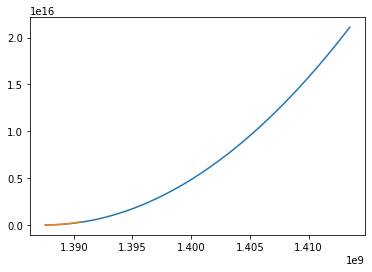

In [240]:
f0 = 10
Mc = 1e-6 * 2e30
beta = const*f0**(8/3)*Mc**(5/3)
t_space = np.linspace(start_time+0*day, start_time+300*day, int(1e5))
f_source = f_calc(f0, beta, t_space - t_space[0])
f_doppler = f_source*(1+np.dot(interp_v(t_space), n_hat))
phi_source = phi_calc(f0, beta, t_space - t_space[0])
phi_source -= phi_source[0] #be careful with this
integrated_phi = integrate.cumulative_trapezoid(phi_source, x=t_space, initial=0)

pl.plot(t_space, integrated_phi)

f0 = 10
Mc = 1e-3 * 2e30
beta = const*f0**(8/3)*Mc**(5/3)
t_space = np.linspace(start_time+0*day, start_time+300*day, int(1e5))
f_source = f_calc(f0, beta, t_space - t_space[0])
f_doppler = f_source*(1+np.dot(interp_v(t_space), n_hat))
phi_source = phi_calc(f0, beta, t_space - t_space[0])
phi_source -= phi_source[0] #be careful with this
integrated_phi = integrate.cumulative_trapezoid(phi_source, x=t_space, initial=0)

f0 = 10
Mc = 1e-2 * 2e30
beta = const*f0**(8/3)*Mc**(5/3)
t_space = np.linspace(start_time+0*day, start_time+300*day, int(1e5))
f_source = f_calc(f0, beta, t_space - t_space[0])
f_doppler = f_source*(1+np.dot(interp_v(t_space), n_hat))
phi_source = phi_calc(f0, beta, t_space - t_space[0])
phi_source -= phi_source[0] #be careful with this
integrated_phi = integrate.cumulative_trapezoid(phi_source, x=t_space, initial=0)

pl.plot(t_space, integrated_phi)

Why factor of 1/2?


/home/neil/anaconda3/envs/PBHs/lib/python3.7/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in true_divide
  """Entry point for launching an IPython kernel.


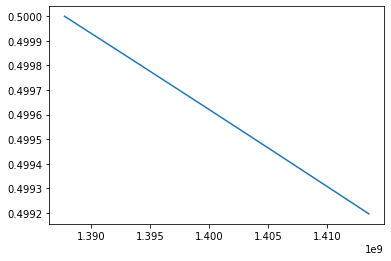

In [201]:
pl.plot(t_space, integrated_phi/analytical_integrated)
# pl.plot(t_space, analytical_integrated)
print("Why factor of 1/2?")

In [202]:
phi_approx = phi_source * (1+np.dot(interp_v(t_space), n_hat))\
             -np.dot(interp_acc(t_space), n_hat)*integrated_phi

f_approx = 1/(2*pi)*np.gradient(phi_approx, np.diff(t_space)[0])

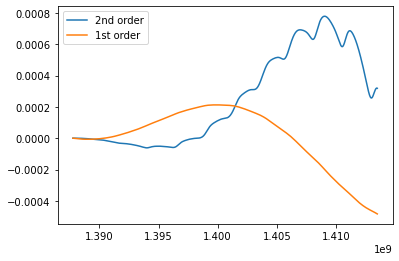

In [203]:
pl.plot(t_space, (f_approx - f_doppler)/f_doppler, label='2nd order')
pl.plot(t_space, (f_order1 - f_doppler)/f_doppler, label='1st order')
pl.legend()

## Numerically integrating

### For the second order correction

$$\phi^{doppler}(t) = \phi^0(t) (1+\frac{\vec{v} \cdot \hat{n}}{c})-\int \frac{\vec{a} \cdot \hat{n}}{c}\phi^0(t)dt$$

In [180]:
from scipy import integrate
phi_source = phi_calc(f0, beta, t_space - t_space[0])
phi_source -= phi_source[0]
phi_approx = phi_source * (1+np.dot(interp_v(t_space), n_hat))
temp = np.dot(interp_acc(t_space), n_hat)*phi_source

numerical = integrate.cumulative_trapezoid(temp, x=t_space, initial=0)
numerical_f = 1/(2*pi)*np.gradient(phi_approx-numerical, np.diff(t_space)[0])

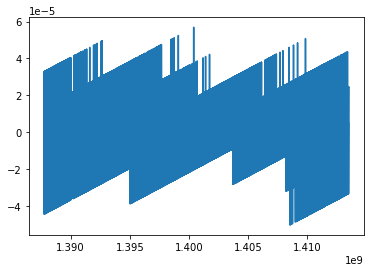

In [181]:
# pl.plot(t_space, (f_doppler - f_approx))
pl.plot(t_space, f_doppler - numerical_f)

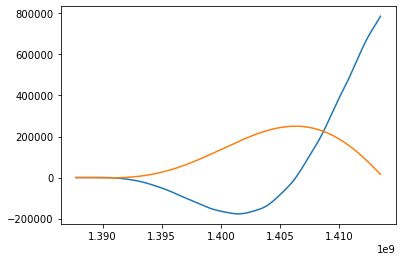

In [182]:
# pl.plot(t_space, numerical)
pl.plot(t_space, -integrated_phi*np.dot(interp_acc(t_space), n_hat))
pl.plot(t_space, numerical)

### Integrating directly

$$\phi^{doppler}(t) = \int f^0(t) (1+\frac{\vec{v} \cdot \hat{n}}{c})dt$$

In [183]:
numerical_phi = 2*np.pi*integrate.cumulative_trapezoid(f_doppler, x=t_space, initial=0)
numerical_f = 1/(2*pi)*np.gradient(numerical_phi, np.diff(t_space)[0])

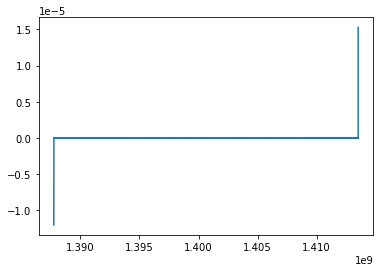

In [140]:
# pl.plot(t_space, (f_doppler - f_approx))
pl.plot(t_space, f_doppler - numerical_f)

## Finding hints

If you believe that $$\phi^{doppler} = \phi^{source}(1+X(t))$$ we can find the form of X(t) and try to recognise it

/home/neil/anaconda3/envs/PBHs/lib/python3.7/site-packages/ipykernel_launcher.py:14: RuntimeWarning: invalid value encountered in true_divide
  
/home/neil/anaconda3/envs/PBHs/lib/python3.7/site-packages/ipykernel_launcher.py:27: RuntimeWarning: invalid value encountered in true_divide
/home/neil/anaconda3/envs/PBHs/lib/python3.7/site-packages/ipykernel_launcher.py:40: RuntimeWarning: invalid value encountered in true_divide


Text(0.5, 1.0, 'Changing f0')

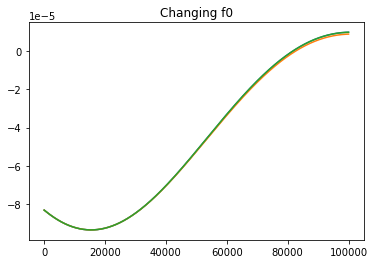

In [148]:
f0_arr = [10, 20, 40, 80]

# for f in f0_arr:
#     f0 = f
Mc = 1e-4 * 2e30
beta = const*f0**(8/3)*Mc**(5/3)
f_source = f_calc(f0, beta, t_space - t_space[0])
f_doppler = f_source*(1+np.dot(interp_v(t_space), n_hat))
numerical_phi = 2*np.pi*integrate.cumulative_trapezoid(f_doppler, x=t_space, initial=0)

phi_source = phi_calc(f0, beta, t_space - t_space[0])
phi_source -= phi_source[0] #be careful with this
order1 = phi_source * (1+np.dot(interp_v(t_space), n_hat))
temp0 = (numerical_phi/phi_source)-1
pl.plot(temp0)

f0 = 20
Mc = 1e-4 * 2e30
beta = const*f0**(8/3)*Mc**(5/3)
f_source = f_calc(f0, beta, t_space - t_space[0])
f_doppler = f_source*(1+np.dot(interp_v(t_space), n_hat))
numerical_phi = 2*np.pi*integrate.cumulative_trapezoid(f_doppler, x=t_space, initial=0)

phi_source = phi_calc(f0, beta, t_space - t_space[0])
phi_source -= phi_source[0] #be careful with this
order1 = phi_source * (1+np.dot(interp_v(t_space), n_hat))
temp1 = (numerical_phi/phi_source)-1
pl.plot(temp1)

f0 = 40
Mc = 1e-4 * 2e30
beta = const*f0**(8/3)*Mc**(5/3)
f_source = f_calc(f0, beta, t_space - t_space[0])
f_doppler = f_source*(1+np.dot(interp_v(t_space), n_hat))
numerical_phi = 2*np.pi*integrate.cumulative_trapezoid(f_doppler, x=t_space, initial=0)

phi_source = phi_calc(f0, beta, t_space - t_space[0])
phi_source -= phi_source[0] #be careful with this
order1 = phi_source * (1+np.dot(interp_v(t_space), n_hat))
temp2 = (numerical_phi/phi_source)-1
pl.plot(temp2)
pl.title("Changing f0")

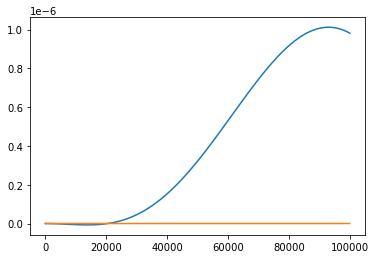

In [149]:
pl.plot(temp0-temp1)
pl.plot(temp0-temp2)

/home/neil/anaconda3/envs/PBHs/lib/python3.7/site-packages/ipykernel_launcher.py:11: RuntimeWarning: invalid value encountered in true_divide
  # This is added back by InteractiveShellApp.init_path()
/home/neil/anaconda3/envs/PBHs/lib/python3.7/site-packages/ipykernel_launcher.py:23: RuntimeWarning: invalid value encountered in true_divide
/home/neil/anaconda3/envs/PBHs/lib/python3.7/site-packages/ipykernel_launcher.py:35: RuntimeWarning: invalid value encountered in true_divide


Text(0.5, 1.0, 'Changing Mc')

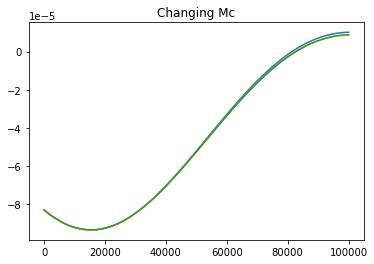

In [143]:
f0 = 10
Mc = 1e-3 * 2e30
beta = const*f0**(8/3)*Mc**(5/3)
f_source = f_calc(f0, beta, t_space - t_space[0])
f_doppler = f_source*(1+np.dot(interp_v(t_space), n_hat))
numerical_phi = 2*np.pi*integrate.cumulative_trapezoid(f_doppler, x=t_space, initial=0)

phi_source = phi_calc(f0, beta, t_space - t_space[0])
phi_source -= phi_source[0] #be careful with this
order1 = phi_source * (1+np.dot(interp_v(t_space), n_hat))
pl.plot((numerical_phi/phi_source)-1)

f0 = 10
Mc = 1e-4 * 2e30
beta = const*f0**(8/3)*Mc**(5/3)
f_source = f_calc(f0, beta, t_space - t_space[0])
f_doppler = f_source*(1+np.dot(interp_v(t_space), n_hat))
numerical_phi = 2*np.pi*integrate.cumulative_trapezoid(f_doppler, x=t_space, initial=0)

phi_source = phi_calc(f0, beta, t_space - t_space[0])
phi_source -= phi_source[0] #be careful with this
order1 = phi_source * (1+np.dot(interp_v(t_space), n_hat))
pl.plot((numerical_phi/phi_source)-1)

f0 = 10
Mc = 1e-5 * 2e30
beta = const*f0**(8/3)*Mc**(5/3)
f_source = f_calc(f0, beta, t_space - t_space[0])
f_doppler = f_source*(1+np.dot(interp_v(t_space), n_hat))
numerical_phi = 2*np.pi*integrate.cumulative_trapezoid(f_doppler, x=t_space, initial=0)

phi_source = phi_calc(f0, beta, t_space - t_space[0])
phi_source -= phi_source[0] #be careful with this
order1 = phi_source * (1+np.dot(interp_v(t_space), n_hat))
pl.plot((numerical_phi/phi_source)-1)
pl.title("Changing Mc")

Alternately if it's of the form $$\phi^{doppler} = \phi^0(t) (1+\frac{\vec{v} \cdot \hat{n}}{c})(1+X(t))$$

/home/neil/anaconda3/envs/PBHs/lib/python3.7/site-packages/ipykernel_launcher.py:11: RuntimeWarning: invalid value encountered in true_divide
  # This is added back by InteractiveShellApp.init_path()
/home/neil/anaconda3/envs/PBHs/lib/python3.7/site-packages/ipykernel_launcher.py:23: RuntimeWarning: invalid value encountered in true_divide
/home/neil/anaconda3/envs/PBHs/lib/python3.7/site-packages/ipykernel_launcher.py:35: RuntimeWarning: invalid value encountered in true_divide


Text(0.5, 1.0, 'Changing f0')

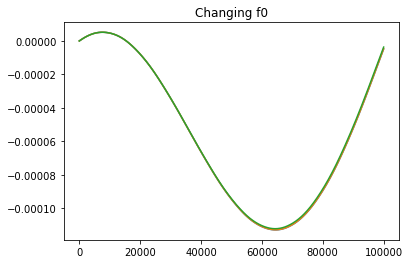

In [150]:
f0 = 10
Mc = 1e-4 * 2e30
beta = const*f0**(8/3)*Mc**(5/3)
f_source = f_calc(f0, beta, t_space - t_space[0])
f_doppler = f_source*(1+np.dot(interp_v(t_space), n_hat))
numerical_phi = 2*np.pi*integrate.cumulative_trapezoid(f_doppler, x=t_space, initial=0)

phi_source = phi_calc(f0, beta, t_space - t_space[0])
phi_source -= phi_source[0] #be careful with this
order1 = phi_source * (1+np.dot(interp_v(t_space), n_hat))
pl.plot((numerical_phi/order1)-1)

f0 = 20
Mc = 1e-4 * 2e30
beta = const*f0**(8/3)*Mc**(5/3)
f_source = f_calc(f0, beta, t_space - t_space[0])
f_doppler = f_source*(1+np.dot(interp_v(t_space), n_hat))
numerical_phi = 2*np.pi*integrate.cumulative_trapezoid(f_doppler, x=t_space, initial=0)

phi_source = phi_calc(f0, beta, t_space - t_space[0])
phi_source -= phi_source[0] #be careful with this
order1 = phi_source * (1+np.dot(interp_v(t_space), n_hat))
pl.plot((numerical_phi/order1)-1)

f0 = 40
Mc = 1e-4 * 2e30
beta = const*f0**(8/3)*Mc**(5/3)
f_source = f_calc(f0, beta, t_space - t_space[0])
f_doppler = f_source*(1+np.dot(interp_v(t_space), n_hat))
numerical_phi = 2*np.pi*integrate.cumulative_trapezoid(f_doppler, x=t_space, initial=0)

phi_source = phi_calc(f0, beta, t_space - t_space[0])
phi_source -= phi_source[0] #be careful with this
order1 = phi_source * (1+np.dot(interp_v(t_space), n_hat))
pl.plot((numerical_phi/order1)-1)
pl.title("Changing f0")

/home/neil/anaconda3/envs/PBHs/lib/python3.7/site-packages/ipykernel_launcher.py:11: RuntimeWarning: invalid value encountered in true_divide
  # This is added back by InteractiveShellApp.init_path()
/home/neil/anaconda3/envs/PBHs/lib/python3.7/site-packages/ipykernel_launcher.py:23: RuntimeWarning: invalid value encountered in true_divide
/home/neil/anaconda3/envs/PBHs/lib/python3.7/site-packages/ipykernel_launcher.py:35: RuntimeWarning: invalid value encountered in true_divide


Text(0.5, 1.0, 'Changing Mc')

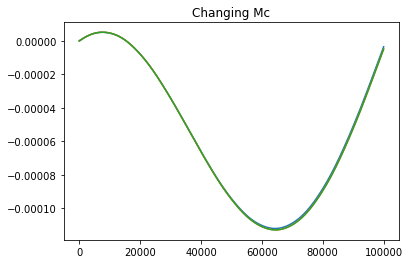

In [156]:
f0 = 10
Mc = 1e-3 * 2e30
beta = const*f0**(8/3)*Mc**(5/3)
f_source = f_calc(f0, beta, t_space - t_space[0])
f_doppler = f_source*(1+np.dot(interp_v(t_space), n_hat))
numerical_phi = 2*np.pi*integrate.cumulative_trapezoid(f_doppler, x=t_space, initial=0)

phi_source = phi_calc(f0, beta, t_space - t_space[0])
phi_source -= phi_source[0] #be careful with this
order1 = phi_source * (1+np.dot(interp_v(t_space), n_hat))
pl.plot((numerical_phi/order1)-1)

f0 = 10
Mc = 1e-4 * 2e30
beta = const*f0**(8/3)*Mc**(5/3)
f_source = f_calc(f0, beta, t_space - t_space[0])
f_doppler = f_source*(1+np.dot(interp_v(t_space), n_hat))
numerical_phi = 2*np.pi*integrate.cumulative_trapezoid(f_doppler, x=t_space, initial=0)

phi_source = phi_calc(f0, beta, t_space - t_space[0])
phi_source -= phi_source[0] #be careful with this
order1 = phi_source * (1+np.dot(interp_v(t_space), n_hat))
pl.plot((numerical_phi/order1)-1)

f0 = 10
Mc = 1e-5 * 2e30
beta = const*f0**(8/3)*Mc**(5/3)
f_source = f_calc(f0, beta, t_space - t_space[0])
f_doppler = f_source*(1+np.dot(interp_v(t_space), n_hat))
numerical_phi = 2*np.pi*integrate.cumulative_trapezoid(f_doppler, x=t_space, initial=0)

phi_source = phi_calc(f0, beta, t_space - t_space[0])
phi_source -= phi_source[0] #be careful with this
order1 = phi_source * (1+np.dot(interp_v(t_space), n_hat))
pl.plot((numerical_phi/order1)-1)
pl.title("Changing Mc")

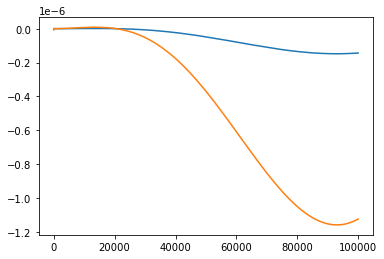

In [157]:
pl.plot(temp0-temp1)
pl.plot(temp0-temp2)

/home/neil/anaconda3/envs/PBHs/lib/python3.7/site-packages/ipykernel_launcher.py:11: RuntimeWarning: invalid value encountered in true_divide
  # This is added back by InteractiveShellApp.init_path()
/home/neil/anaconda3/envs/PBHs/lib/python3.7/site-packages/ipykernel_launcher.py:24: RuntimeWarning: invalid value encountered in true_divide
/home/neil/anaconda3/envs/PBHs/lib/python3.7/site-packages/ipykernel_launcher.py:37: RuntimeWarning: invalid value encountered in true_divide


Text(0.5, 1.0, 'Changing f0')

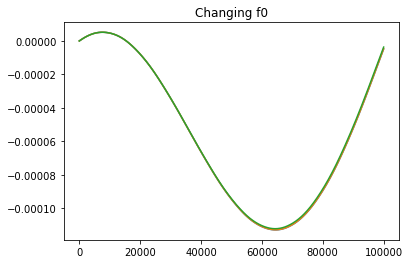

In [158]:
f0 = 10
Mc = 1e-4 * 2e30
beta = const*f0**(8/3)*Mc**(5/3)
f_source = f_calc(f0, beta, t_space - t_space[0])
f_doppler = f_source*(1+np.dot(interp_v(t_space), n_hat))
numerical_phi = 2*np.pi*integrate.cumulative_trapezoid(f_doppler, x=t_space, initial=0)

phi_source = phi_calc(f0, beta, t_space - t_space[0])
phi_source -= phi_source[0] #be careful with this
order1 = phi_source * (1+np.dot(interp_v(t_space), n_hat))
temp0 = (numerical_phi/order1)-1
pl.plot(temp0)

f0 = 20
Mc = 1e-4 * 2e30
beta = const*f0**(8/3)*Mc**(5/3)
f_source = f_calc(f0, beta, t_space - t_space[0])
f_doppler = f_source*(1+np.dot(interp_v(t_space), n_hat))
numerical_phi = 2*np.pi*integrate.cumulative_trapezoid(f_doppler, x=t_space, initial=0)

phi_source = phi_calc(f0, beta, t_space - t_space[0])
phi_source -= phi_source[0] #be careful with this
order1 = phi_source * (1+np.dot(interp_v(t_space), n_hat))
temp1 = (numerical_phi/order1)-1
pl.plot(temp1)

f0 = 40
Mc = 1e-4 * 2e30
beta = const*f0**(8/3)*Mc**(5/3)
f_source = f_calc(f0, beta, t_space - t_space[0])
f_doppler = f_source*(1+np.dot(interp_v(t_space), n_hat))
numerical_phi = 2*np.pi*integrate.cumulative_trapezoid(f_doppler, x=t_space, initial=0)

phi_source = phi_calc(f0, beta, t_space - t_space[0])
phi_source -= phi_source[0] #be careful with this
order1 = phi_source * (1+np.dot(interp_v(t_space), n_hat))
temp2 = (numerical_phi/order1)-1
pl.plot(temp2)
pl.title("Changing f0")

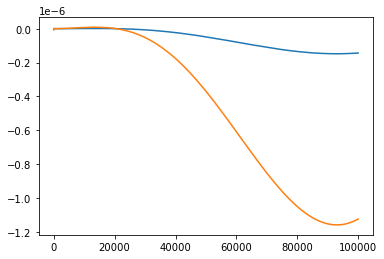

In [159]:
pl.plot(temp0-temp1)
pl.plot(temp0-temp2)